In [23]:
import numpy as np
import matplotlib.pyplot as plt

## Load data for training

In [24]:
Xtrain = np.loadtxt('Xtrain.csv')
Ytrain = np.loadtxt('Ytrain.csv')
Ntrain = Xtrain.shape[0]

10

## Define the feature function $\phi(x)$

In [25]:
P = 1

def phi(x):
    N = x.shape[0]
    phix = np.empty((N,P))
    for p in range(0,P):
        phix[:,p] = x**(p+1)
    return phix

## Build the feature matrix $\Phi$

In [26]:
Phi = np.empty((Ntrain,P+1))
Phi[:,0] = 1
Phi[:,1:] = phi(Xtrain)

## Solve linear regression: $\quad\underline{\hat\theta}^c = (\Phi^T \Phi)^{-1}\Phi^T Y$

In [27]:
thetahat = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ Ytrain

## Define the prediction function: $\quad h(x) = \hat\theta_0 + \phi(x) \: \underline{\hat\theta}_1$

In [28]:
def h(x,thetahat):
    thetahat0 = thetahat[0]
    thetahat1 = thetahat[1:]

    yhat = thetahat0
    for p in range(P):
        yhat += thetahat1[p] * x**(p+1)

    return yhat

## Compute $\hat y$ for the training data

In [29]:
yhat_train = h(Xtrain,thetahat)

## Define the performance metric: $\quad\text{MSE}=\sum (y_i-\hat{y}_i)^2$

In [30]:
def MSE(y,yhat):
    return np.mean((y-yhat)**2)

## Evaluate the performance on the training data

In [31]:
MSE_train = MSE(Ytrain,yhat_train)

## Do the same for a test dataset:

In [32]:
Xtest = np.loadtxt('Xtest.csv')
Ytest = np.loadtxt('Ytest.csv')
Ntest = Xtest.shape[0]
yhat_test = h(Xtest,thetahat)
MSE_test = MSE(Ytest,yhat_test)

## Plot

(-2.0, 2.0)

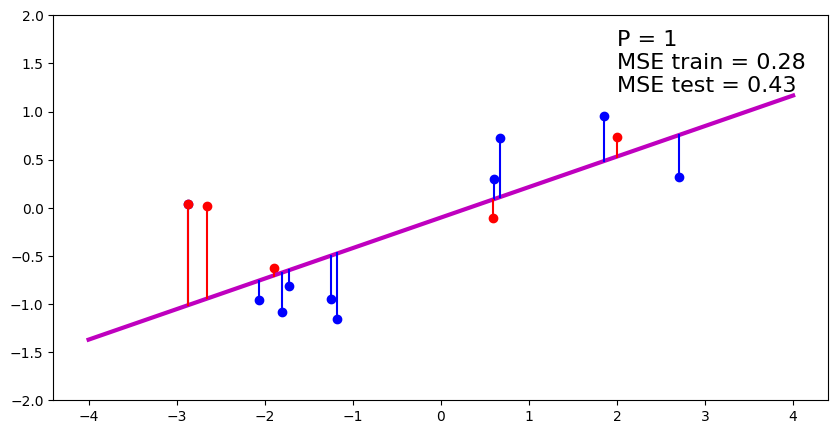

In [33]:
x = np.linspace(-4,4,100)

fig = plt.figure(figsize=(10,5))
ax = plt.subplot()
ax.scatter(Xtrain,Ytrain,c='b')
ax.scatter(Xtest,Ytest,c='r')
ax.plot(x,h(x,thetahat),c='m',linewidth=3)

for i in range(Ntrain):
    ax.plot([Xtrain[i],Xtrain[i]],[Ytrain[i],yhat_train[i]],color='b')

for i in range(Ntest):
    ax.plot([Xtest[i],Xtest[i]],[Ytest[i],yhat_test[i]],color='r')

ax.text(2,1.2,f'P = {P}\nMSE train = {MSE_train:.2f}\nMSE test = {MSE_test:.2f}',fontsize=16)

ax.set_ylim(-2,2)